# Use Keras and hyperparameter optimization (HPO) to recognize hand-written digits with `ibm-watsonx-ai`

This notebook contains steps and code to demonstrate support of Deep Learning experiments in the watsonx.ai service. It introduces commands for data retrieval, training definition persistence, experiment training, model persistence, model deployment and scoring.

Some familiarity with Python is helpful. This notebook uses Python 3.12.

**Note:** To use Deep Learning experiments, you must install and configure the IBM® Software Hub scheduling service.

## Learning goals

The learning goals of this notebook are:

-  Working with the watsonx.ai service.
-  Training Deep Learning models (TensorFlow).
-  Saving trained models in watsonx.ai repository.
-  Online deployment and scoring of the trained model.

## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Create model definition](#2.-Create-model-definition)
3. [Train model](#3.-Train-model)
4. [Persist trained model](#4.-Persist-trained-model)
5. [Deploy and score](#5.-Deploy-and-score)
6. [Cleanup](#6.-Cleanup)
7. [Summary and next steps](#7.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Contact with your IBM Cloud Pak® for Data administrator and ask them for your account credentials

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install -U wget | tail -n 1
%pip install -U matplotlib | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [2]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.3",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.3",
    )

#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.3/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [5]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai, you need to set **space** which you will be using.

In [6]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Create-model-definition"></a>
## 2. Create model definition

For the purpose of this example two Keras model definitions have been prepared:

 - Multilayer Perceptron (MLP)
 - Convolution Neural Network (CNN)

### 2.1 Prepare model definition metadata

In [7]:
meta_props = {
    client.model_definitions.ConfigurationMetaNames.NAME: "MNIST mlp model definition",
    client.model_definitions.ConfigurationMetaNames.DESCRIPTION: "MNIST mlp model definition",
    client.model_definitions.ConfigurationMetaNames.COMMAND: "mnist_mlp.py",
    client.model_definitions.ConfigurationMetaNames.PLATFORM: {
        "name": "python",
        "versions": ["3.11"],
    },
    client.model_definitions.ConfigurationMetaNames.VERSION: "2.0",
}

### 2.2 Get sample model definition content files from git (Python scripts with CNN and MLP)

In [8]:
import os

import wget

filename_mnist = "MNIST.zip"

if not os.path.isfile(filename_mnist):
    filename_mnist = wget.download(
        "https://github.com/IBM/watsonx-ai-samples/raw/master/cpd5.3/definitions/keras/mnist/MNIST.zip"
    )

**Tip**: To see model definition's code, run the following command:
```sh
unzip -oqd . MNIST.zip && cat mnist_mlp.py
```

### 2.3 Publish model definition

In [9]:
model_definition_details = client.model_definitions.store(
    filename_mnist, meta_props=meta_props
)

In [10]:
model_definition_id = client.model_definitions.get_id(model_definition_details)
print(model_definition_id)

93ad6ae8-3d1e-4f1f-a43f-085e7323e31b


#### List model definitions

In [11]:
client.model_definitions.list()

,NAME,ASSET_TYPE,ID
0,MNIST mlp model definition,wml_model_definition,93ad6ae8-3d1e-4f1f-a43f-085e7323e31b


<a id="3.-Train-model"></a>
## 3. Train model

### 3.1 Prepare training metadata

In [12]:
training_metadata = {
    client.training.ConfigurationMetaNames.NAME: "Keras-MNIST",
    client.training.ConfigurationMetaNames.DESCRIPTION: "Keras-MNIST predict written digits",
    client.training.ConfigurationMetaNames.TRAINING_RESULTS_REFERENCE: {
        "name": "MNIST results",
        "connection": {},
        "location": {"path": f"spaces/{space_id}/assets/experiment"},
        "type": "fs",
    },
    client.training.ConfigurationMetaNames.MODEL_DEFINITION: {
        "id": model_definition_id,
        "hardware_spec": {
            "name": "CPUx4",
            "nodes": 1,
        },  # To use GPU for training, set hardware_spec.name to `GPUx1` for example
        "software_spec": {"name": "tensorflow_rt24.1-py3.11"},
    },
    client.training.ConfigurationMetaNames.TRAINING_DATA_REFERENCES: [
        {
            "name": "training_input_data",
            "type": "fs",
            "connection": {},
            "location": {"path": "tf-mnist"},
            "schema": {
                "id": "idmlp_schema",
                "fields": [{"name": "text", "type": "string"}],
            },
        }
    ],
}

### 3.2 Train the model

In [13]:
training = client.training.run(training_metadata, asynchronous=False)



##############################################

Running 'dcf69448-02fc-4119-a93d-eccee75ff65b'

##############################################


pending....
running.................
completed
Training of 'dcf69448-02fc-4119-a93d-eccee75ff65b' finished successfully.


### 3.3 Get training ID

In [14]:
training_id = client.training.get_id(training)

### 3.4 Get training details

In [15]:
import json

training_details = client.training.get_details(training_id)
print(json.dumps(training_details, indent=2))

{
  "metadata": {
    "created_at": "2025-11-19T08:30:01.443Z",
    "description": "Keras-MNIST predict written digits",
    "id": "dcf69448-02fc-4119-a93d-eccee75ff65b",
    "modified_at": "2025-11-19T08:32:09.603Z",
    "name": "Keras-MNIST",
    "space_id": "e4509fba-55db-48c5-94a6-08c399762bf2"
  },
  "entity": {
    "model_definition": {
      "hardware_spec": {
        "name": "CPUx4"
      },
      "id": "93ad6ae8-3d1e-4f1f-a43f-085e7323e31b",
      "software_spec": {
        "name": "tensorflow_rt24.1-py3.11"
      }
    },
    "results_reference": {
      "connection": {},
      "location": {
        "path": "spaces/e4509fba-55db-48c5-94a6-08c399762bf2/assets/experiment",
        "model": "spaces/e4509fba-55db-48c5-94a6-08c399762bf2/assets/experiment/dcf69448-02fc-4119-a93d-eccee75ff65b/data/model",
        "notebooks_path": "spaces/e4509fba-55db-48c5-94a6-08c399762bf2/assets/experiment/dcf69448-02fc-4119-a93d-eccee75ff65b/notebooks",
        "training": "spaces/e4509fba-55db-

#### List trainings

In [16]:
client.training.list()

,ID (training),STATE,CREATED
0,dcf69448-02fc-4119-a93d-eccee75ff65b,completed,2025-11-19T08:30:01.443Z


#### Cancel training

You can cancel the training run by calling `client.training.cancel(training_id)`.

**Tip**: If you want to delete train runs and results, add `hard_delete=True` as a parameter.

<a id="4.-Persist-trained-model"></a>
## 4. Persist trained model

### 4.1 Publish model

In [17]:
software_spec_id = client.software_specifications.get_id_by_name(
    "tensorflow_rt24.1-py3.11"
)

In [18]:
model_meta_props = {
    client.repository.ModelMetaNames.NAME: "Keras MNIST",
    client.repository.ModelMetaNames.TYPE: "tensorflow_2.14",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_ID: software_spec_id,
}

published_model = client.repository.store_model(
    training_id, meta_props=model_meta_props
)
model_id = client.repository.get_model_id(published_model)

### 4.2 Get model details

In [19]:
model_details = client.repository.get_details(model_id)
print(json.dumps(model_details, indent=2))

{
  "metadata": {
    "name": "Keras MNIST",
    "space_id": "e4509fba-55db-48c5-94a6-08c399762bf2",
    "resource_key": "269412eb-62ab-4ada-a2e0-8ea551706ba8",
    "id": "e329a690-51f9-4f1a-a850-d357f1262e6b",
    "created_at": "2025-11-19T08:32:29Z",
    "rov": {
      "member_roles": {
        "1000331001": {
          "user_iam_id": "1000331001",
          "roles": [
            "OWNER"
          ]
        }
      }
    },
    "owner": "1000331001"
  },
  "entity": {
    "model_definition": {
      "id": "93ad6ae8-3d1e-4f1f-a43f-085e7323e31b"
    },
    "software_spec": {
      "id": "2c33167d-b11c-5490-a305-3e5e95db5c4d"
    },
    "type": "tensorflow_rt24.1",
    "training_id": "dcf69448-02fc-4119-a93d-eccee75ff65b",
    "content_location": {
      "type": "fs",
      "location": {
        "assets_path": "spaces/e4509fba-55db-48c5-94a6-08c399762bf2/assets/experiment/dcf69448-02fc-4119-a93d-eccee75ff65b/assets",
        "logs": "spaces/e4509fba-55db-48c5-94a6-08c399762bf2/assets/e

#### List stored models

In [20]:
client.repository.list_models()

,ID,NAME,CREATED,TYPE,SPEC_STATE,SPEC_REPLACEMENT
0,e329a690-51f9-4f1a-a850-d357f1262e6b,Keras MNIST,2025-11-19T08:32:29Z,tensorflow_rt24.1,supported,


<a id="5.-Deploy-and-score"></a>
## 5. Deploy and score

### 5.1 Create online deployment for published model

In [21]:
deployment = client.deployments.create(
    model_id,
    meta_props={
        client.deployments.ConfigurationMetaNames.NAME: "Keras MNIST",
        client.deployments.ConfigurationMetaNames.ONLINE: {},
    },
)

deployment_id = client.deployments.get_id(deployment)



######################################################################################

Synchronous deployment creation for id: 'e329a690-51f9-4f1a-a850-d357f1262e6b' started

######################################################################################


initializing
Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
.....
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='dcb8ab2d-6a98-424e-8029-54c4ec80103f'
-----------------------------------------------------------------------------------------------




### 5.2 Get deployments details

In [22]:
deployments_details = client.deployments.get_details(deployment_id)
print(json.dumps(deployments_details, indent=2))

#### List deployments

In [23]:
client.deployments.list()

,ID,NAME,STATE,CREATED,ARTIFACT_TYPE,SPEC_STATE,SPEC_REPLACEMENT
0,dcb8ab2d-6a98-424e-8029-54c4ec80103f,Keras MNIST,ready,2025-11-19T08:32:37.387Z,model,supported,


### 5.3 Score deployed model

Let's plot two digits. **Action:** Please install `matplotlib`, `numpy`

In [24]:
import wget

dataset_filename = "mnist.npz"

if not os.path.isfile(dataset_filename):
    dataset_filename = wget.download("https://s3.amazonaws.com/img-datasets/mnist.npz")

In [25]:
import numpy as np

mnist_dataset = np.load(dataset_filename)
x_test = mnist_dataset["x_test"]

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

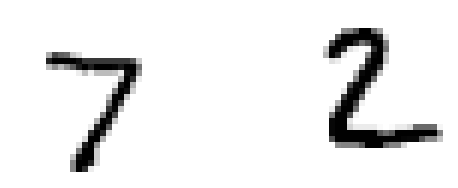

In [27]:
for i, image in enumerate([x_test[0], x_test[1]]):
    plt.subplot(2, 2, i + 1)
    plt.axis("off")
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")

Our input node expects to get data with shape `(784,)` so we need to reshape our two digits.

In [28]:
image_1 = x_test[0].ravel() / 255
image_2 = x_test[1].ravel() / 255

#### Prepare scoring payload and score.

In [29]:
scoring_payload = {
    client.deployments.ScoringMetaNames.INPUT_DATA: [
        {"values": [image_1.tolist(), image_2.tolist()]}
    ]
}
scores = client.deployments.score(deployment_id, meta_props=scoring_payload)
print("Scoring result:\n" + json.dumps(scores, indent=2))

Scoring result:
{
  "predictions": [
    {
      "fields": [
        "prediction",
        "prediction_classes",
        "probability"
      ],
      "id": "dense_2",
      "values": [
        [
          [
            1.0181268050857284e-09,
            4.5325272424179275e-08,
            6.145357360765047e-07,
            1.2214627531648148e-06,
            2.298779569476217e-11,
            5.8711417949552924e-09,
            3.3531966266153734e-13,
            0.9999979734420776,
            3.3742344474063657e-09,
            1.757944545488499e-07
          ],
          7,
          [
            1.0181268050857284e-09,
            4.5325272424179275e-08,
            6.145357360765047e-07,
            1.2214627531648148e-06,
            2.298779569476217e-11,
            5.8711417949552924e-09,
            3.3531966266153734e-13,
            0.9999979734420776,
            3.3742344474063657e-09,
            1.757944545488499e-07
          ]
        ],
        [
          [
      

<a id="6.-Cleanup"></a>
## 6. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.3/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="7.-Summary-and-next-steps"></a>
## 7. Summary and next steps

You successfully completed this notebook! You learned how to use `ibm-watsonx-ai` to run experiments.  

Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Author

**Jan Sołtysik**, Intern at watsonx.ai.

**Rafał Chrzanowski**, Software Engineer Intern at watsonx.ai.

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.